# AG-HYPOPT · Trial 29

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-eight trials are registered; cell 2 reports `phase = trials` (28/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074). Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_21 (0.1074, best):** travel 0.138, balanced gamma; 0 div.
- next best (all 0 div): trial_22 0.1095 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138).
- plateau: trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127, trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (0.194), trial_06 = trial_11 0.1188.
- diverging at 1nW T05 (near-optimum travel): trial_26 0.1368 (0.137), trial_28 0.1370 (0.139). Other diverging: trial_17 0.1329 (0.088), trial_10 0.1975 (0.099), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

State of play: the mu-travel axis is fully mapped (single optimum spike at ~0.137-0.138), but the crucial finding is that the 1nW T05 gamma divergence now strikes roughly half of the near-optimum runs (trials 26 and 28 diverged while 21/22/25 survived), so trial_21's 0.1074 is partly a lucky divergence-free draw and the typical level at the optimum is ~0.110-0.113. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_29'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (28/5 trials)
ID |     ei | params
 1 | 3.2894 | {"gamma_anneal": 0.45569006871430445, "lr_gamma": 0.4142776783077935, "lr_mu": 0.16492923074268293, "mu_anneal": 0.3247454385488865}
 2 | 1.3242 | {"gamma_anneal": 0.21439056478072602, "lr_gamma": 0.4618785019991538, "lr_mu": 0.13573351058023228, "mu_anneal": 0.35106791994699377}
 3 | 1.5418 | {"gamma_anneal": 0.4807662148499209, "lr_gamma": 0.9546283882938371, "lr_mu": 0.1633631554760521, "mu_anneal": 0.32613137390335084}
 4 | 1.4426 | {"gamma_anneal": 0.4563632096348345, "lr_gamma": 0.4342235868904838, "lr_mu": 0.17081409557956032, "mu_anneal": 0.3271896245696585}
 5 | 2.0479 | {"gamma_anneal": 0.4981640779902585, "lr_gamma": 0.4303588702621744, "lr_mu": 0.17008446273937633, "mu_anneal": 0.7928984015440674}
 6 | 3.5114 | {"gamma_anneal": 0.4618202325963348, "lr_gamma": 0.48130054871052286, "lr_mu": 0.15717876317106066, "mu_anneal": 0.3486727611617326}
 7 | 0.7045 | {"gamma_anneal": 0.4833551805318264, "lr_gamma": 0.5318

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (28 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 6: **ei 3.51** — `lr_mu=0.1572`, `mu_anneal=0.3487` (travel **0.130**), `lr_gamma=0.4813`, `gamma_anneal=0.4618`.
- candidate 1: ei 3.29 — `lr_mu=0.1649`, `mu_anneal=0.3247` (travel 0.138), `lr_gamma=0.4143`, `gamma_anneal=0.4557`.
- candidate 5: ei 2.05 — `lr_mu=0.1701`, `mu_anneal=0.7929` (travel 0.103, low), `lr_gamma=0.4304`.
- candidate 3: ei 1.54 — `lr_mu=0.1634`, `mu_anneal=0.3261` (travel 0.137), `lr_gamma=0.9546` (very high).
- candidate 4: ei 1.44 — `lr_mu=0.1708`, `mu_anneal=0.3272` (travel 0.142), `lr_gamma=0.4342`.

Candidate 6 has the highest ei and sits just inside the optimum band (travel 0.130, between trial_15's 0.127 and trial_08's 0.134) with balanced gamma knobs (`lr_gamma=0.4813`, `gamma_anneal=0.4618`) in the proven-safe range. Candidate 1 is at travel 0.138 with similar knobs and close ei. Since the 1nW T05 divergence makes any single run a coin-flip at this region, the sensible move is simply to draw the maximum-ei point there again (candidate 6), which both refines the best region and adds another sample to the divergence statistics. The alternatives carry low travel (candidate 5) or untested extremes (candidate 3's `lr_gamma=0.955`).

I choose candidate 6 (6 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4618202325963348, 'lr_gamma': 0.48130054871052286, 'lr_mu': 0.15717876317106066, 'mu_anneal': 0.3486727611617326}
Running  1nW Trans05 ... 

μ 9.39 -> 9.30 | γ 8.5 -> -16971401445821648.00 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 42.29 | γ 8.5 -> 6.16 | NLL 5.35


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 81.03 | γ 14.1 -> 14.51 | NLL 3.36


Running 3nW Trans100 ... 

μ 175.71 -> 112.20 | γ 14.1 -> 13.94 | NLL 3.15



Total: 9.3 min


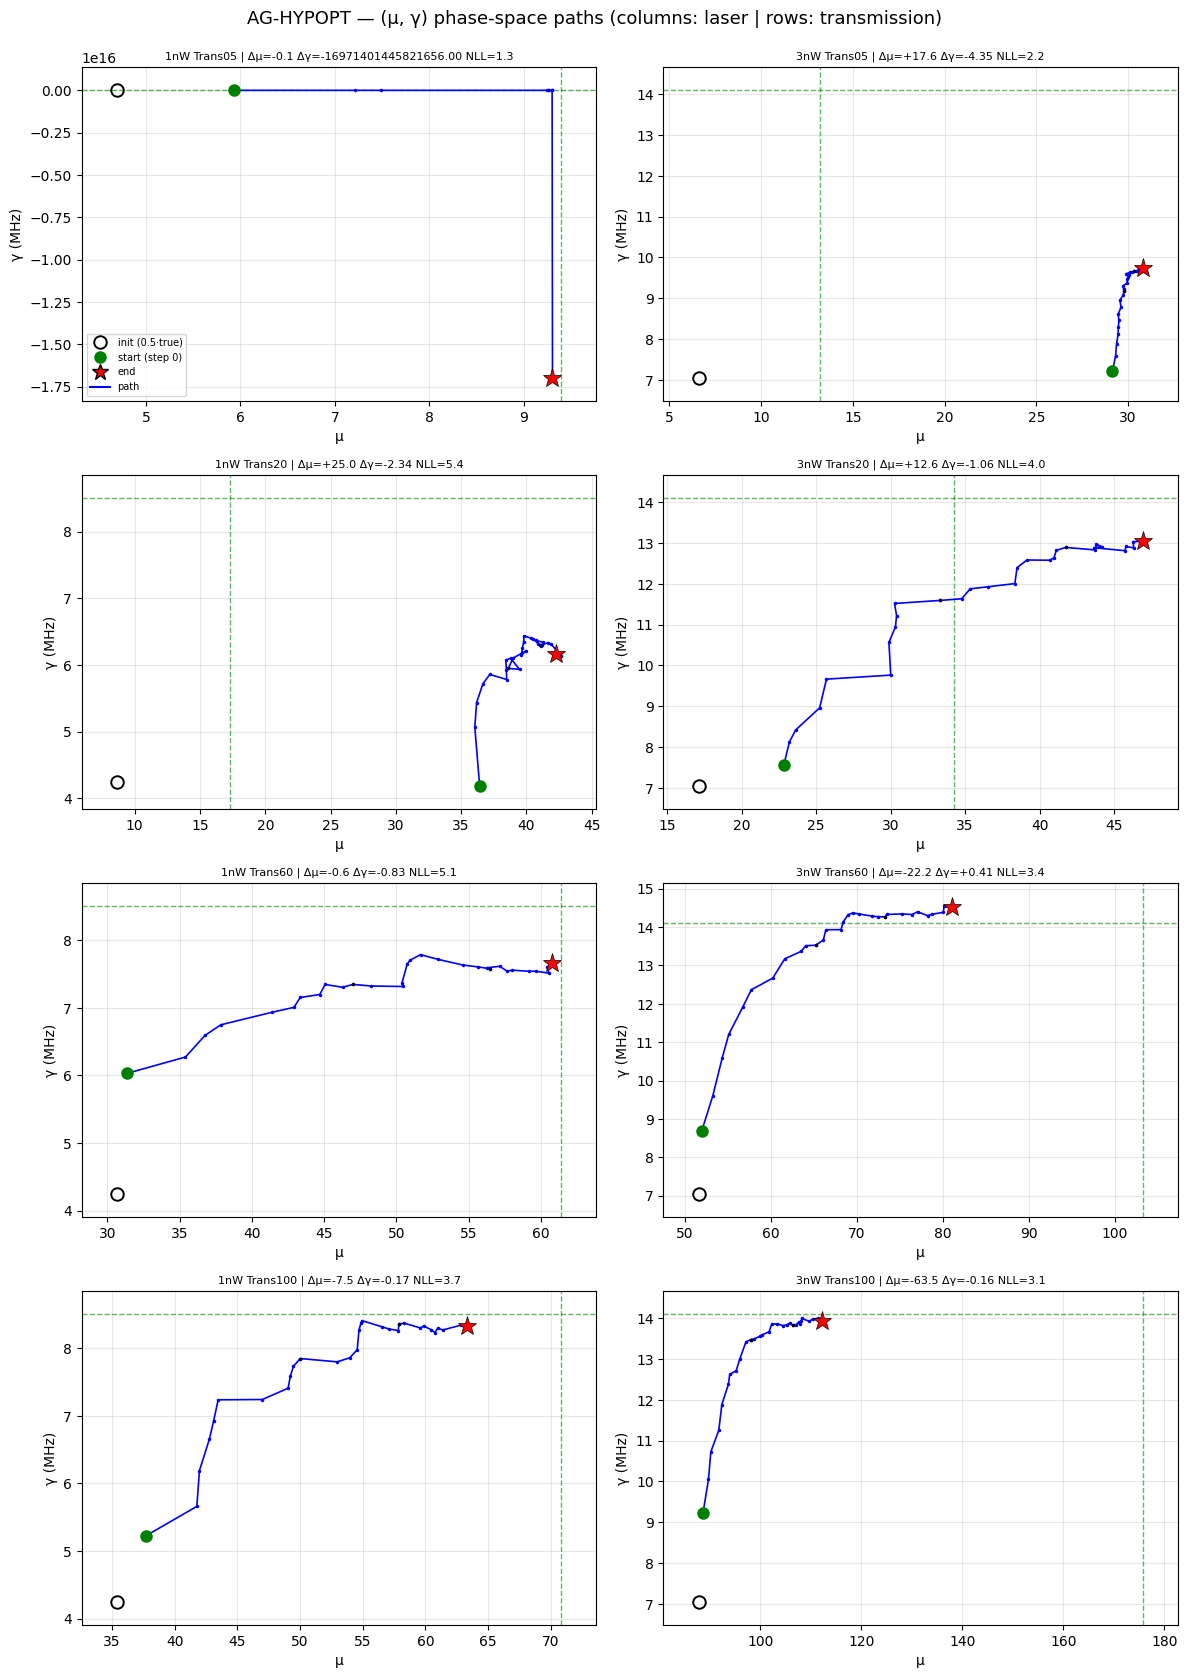

trial finished in 9.4 min
objective = 0.1331 ± 0.0975
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05 !D     9.39    9.30    -0.9 |     8.50-16971401445821648.00-199663546421431264.0
1nW Trans20       17.32   42.29  +144.3 |     8.50    6.16   -27.5
1nW Trans60       61.37   60.77    -1.0 |     8.50    7.67    -9.8
1nW Trans100       70.82   63.31   -10.6 |     8.50    8.33    -2.0
3nW Trans05       13.20   30.79  +133.2 |    14.10    9.75   -30.8
3nW Trans20       34.28   46.90   +36.8 |    14.10   13.04    -7.5
3nW Trans60      103.20   81.03   -21.5 |    14.10   14.51    +2.9
3nW Trans100      175.71  112.20   -36.1 |    14.10   13.94    -1.1

weighted objective (T-graded, cap=1.0) = 0.1331 | diverged cells: 1
μ: RMSE 26.630 (rel 72.3%, bias -4.836) | γ: RMSE 6000296524289835.000 (rel 70591723815174536.0%, bias -2121425180727708.250)


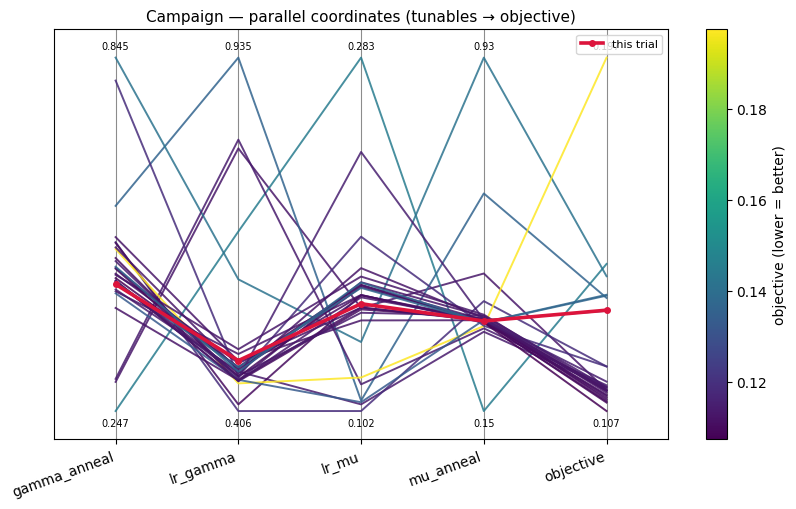

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 29 ran the highest-EI candidate (candidate 6, ei=3.51): `lr_mu=0.1572`, `mu_anneal=0.3487` (effective mu travel 0.130), `lr_gamma=0.4813`, `gamma_anneal=0.4618`. It completed in 9.4 min with objective **0.1331 +/- 0.0975** and **1 diverged cell** (1nW T05: gamma -1.70e16). Ranking: trial_21 0.1074 < ... < **trial_29 0.1331** < ...

Aggregate accuracy: **mu rel-RMSE 72.3%** (RMSE 26.63, bias -4.84) — the other seven cells behaved like a typical 0.11 run; gamma is dominated by the diverged cell (raw RMSE 6.0e15).

Per-cell relative errors (1nW T05 gamma is the diverged value):
- **mu:** 1nW T05 -0.9%, T20 +144.3%, T60 -1.0%, T100 -10.6% | 3nW T05 +133.2%, T20 +36.8%, T60 -21.5%, T100 -36.1%.
- **gamma:** 1nW T05 **diverged (-1.70e16)**, T20 -27.5%, T60 -9.8%, T100 -2.0% | 3nW T05 -30.8%, T20 -7.5%, T60 +2.9%, T100 -1.1%.

This is the third consecutive near-optimum run to diverge at 1nW T05 (trials 26, 28, 29). The split is now clear: the early optimum runs (21, 22, 25) survived the low-count cell, while the three most recent ones all blew up there, with the rest of the configuration behaving normally. At this region the **1nW T05 gamma divergence is roughly a coin flip**, so trial_21's 0.1074 is not reliably reproducible. The meaningful summary of the campaign is therefore the *typical* divergence-free level at the optimum, ~0.110-0.113, with the single 0.1074 as a favourable draw.

**Summary:** Trial 29 (lr_mu=0.1572, mu_anneal=0.3487, lr_gamma=0.4813, gamma_anneal=0.4618): objective 0.1331 +/- 0.0975 with 1 diverged cell (1nW T05, gamma -1.7e16); a third consecutive near-optimum divergence, so the 1nW T05 blow-up now strikes ~half of runs at the optimum.
**Key insight:** Three consecutive near-optimum runs (26, 28, 29) all diverged at 1nW T05 while the earlier three (21, 22, 25) did not, so the low-count gamma divergence is roughly a coin flip at the optimum and the headline best (0.1074) is partly a lucky draw - the honest level is ~0.110-0.113.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The divergence is now unambiguously the dominant source of objective variance (it costs ~0.02-0.07 per affected run) and is not tunable by these four knobs. A robust fix must damp the low-count gamma step (clip the gamma gradient, cap the per-step gamma move, or add a divergence-aware backup at small n_target) - structural, outside this campaign. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 29 (lr_mu=0.1572, mu_anneal=0.3487, lr_gamma=0.4813, gamma_anneal=0.4618): objective 0.1331 +/- 0.0975 with 1 diverged cell (1nW T05, gamma -1.7e16); a third consecutive near-optimum divergence, so the 1nW T05 blow-up now strikes ~half of runs at the optimum"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Three consecutive near-optimum runs (26, 28, 29) all diverged at 1nW T05 while the earlier three (21, 22, 25) did not, so the low-count gamma divergence is roughly a coin flip at the optimum and the headline best (0.1074) is partly a lucky draw - the honest level is ~0.110-0.113"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_29 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_30.ipynb. Open it and follow its cells from the top.
